In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as ptl
import matplotlib.pyplot as plt

Loading The Data From Hugging Face

In [26]:
# Login using e.g. `huggingface-cli login` to access this dataset
df= pd.read_csv("hf://datasets/adegoke655/Insurance/insurance.csv")

In [27]:
# Saving locally as insurance_data.csv
df.to_csv("insurance_data.csv", index=False)

print("Dataset saved successfully as insurance_data.csv")

Dataset saved successfully as insurance_data.csv


Understanding My Data

In [28]:
insurance_data = pd.read_csv("insurance_data.csv")
print(insurance_data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [29]:
insurance_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [30]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Performing Exploratory Data Analysis

In [31]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

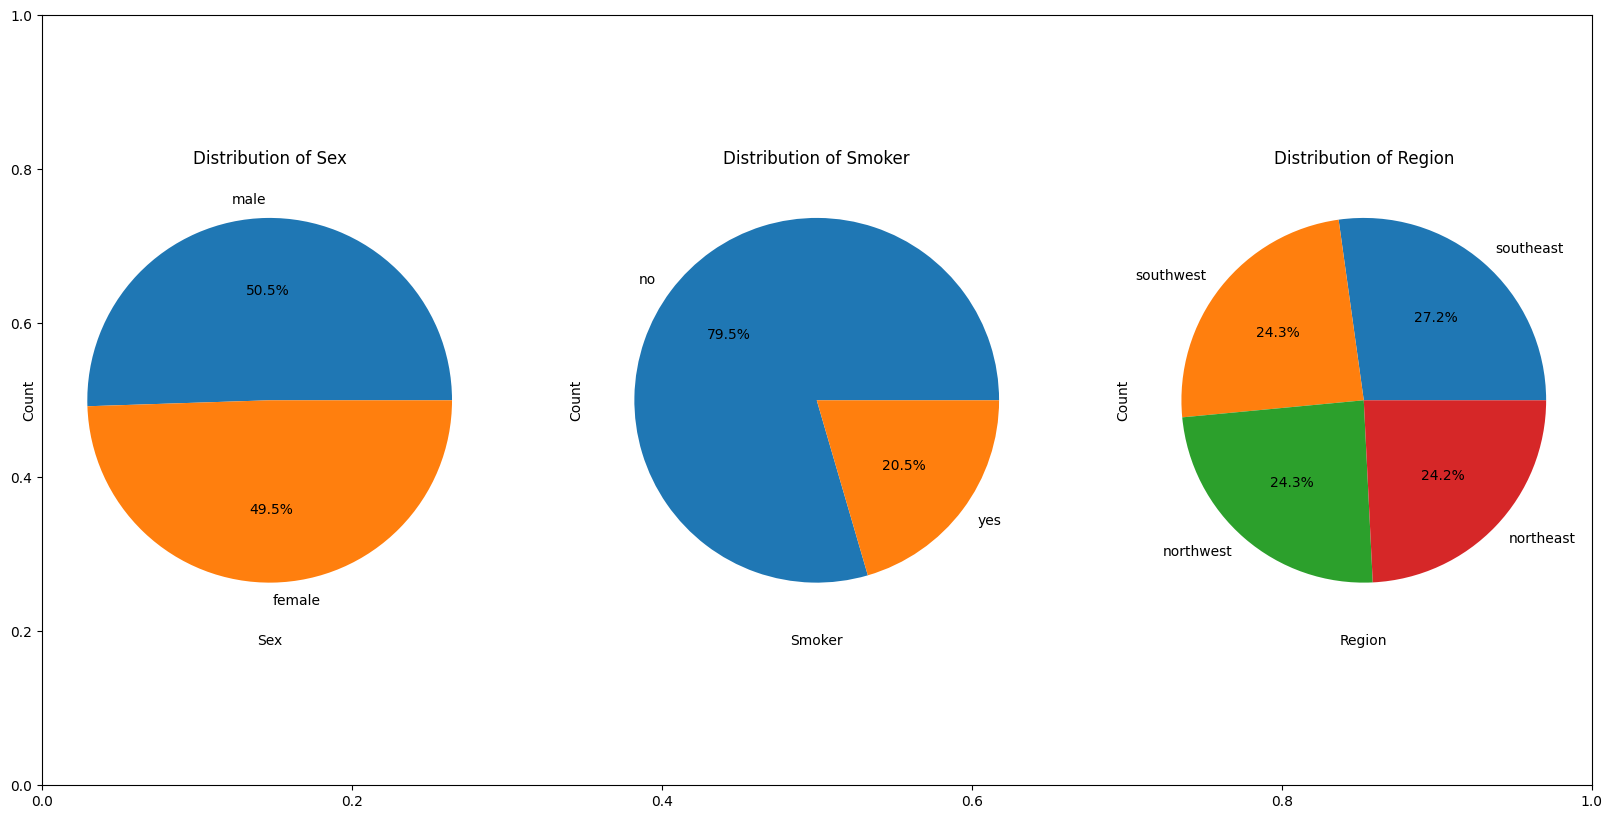

In [32]:
#Plotting the distribution of categorical features
features = ['sex', 'smoker', 'region']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    x = df[col].value_counts()
    plt.pie(x.values,
            labels=x.index,
            autopct='%1.1f%%')

plt.show()

According to the First Piechart,Charges are higher on the higher side for males as compared to females but the difference is very little                                                        
Also the cost charged from the smokers is around thrice that which is charged from non-smokers according to the second graph

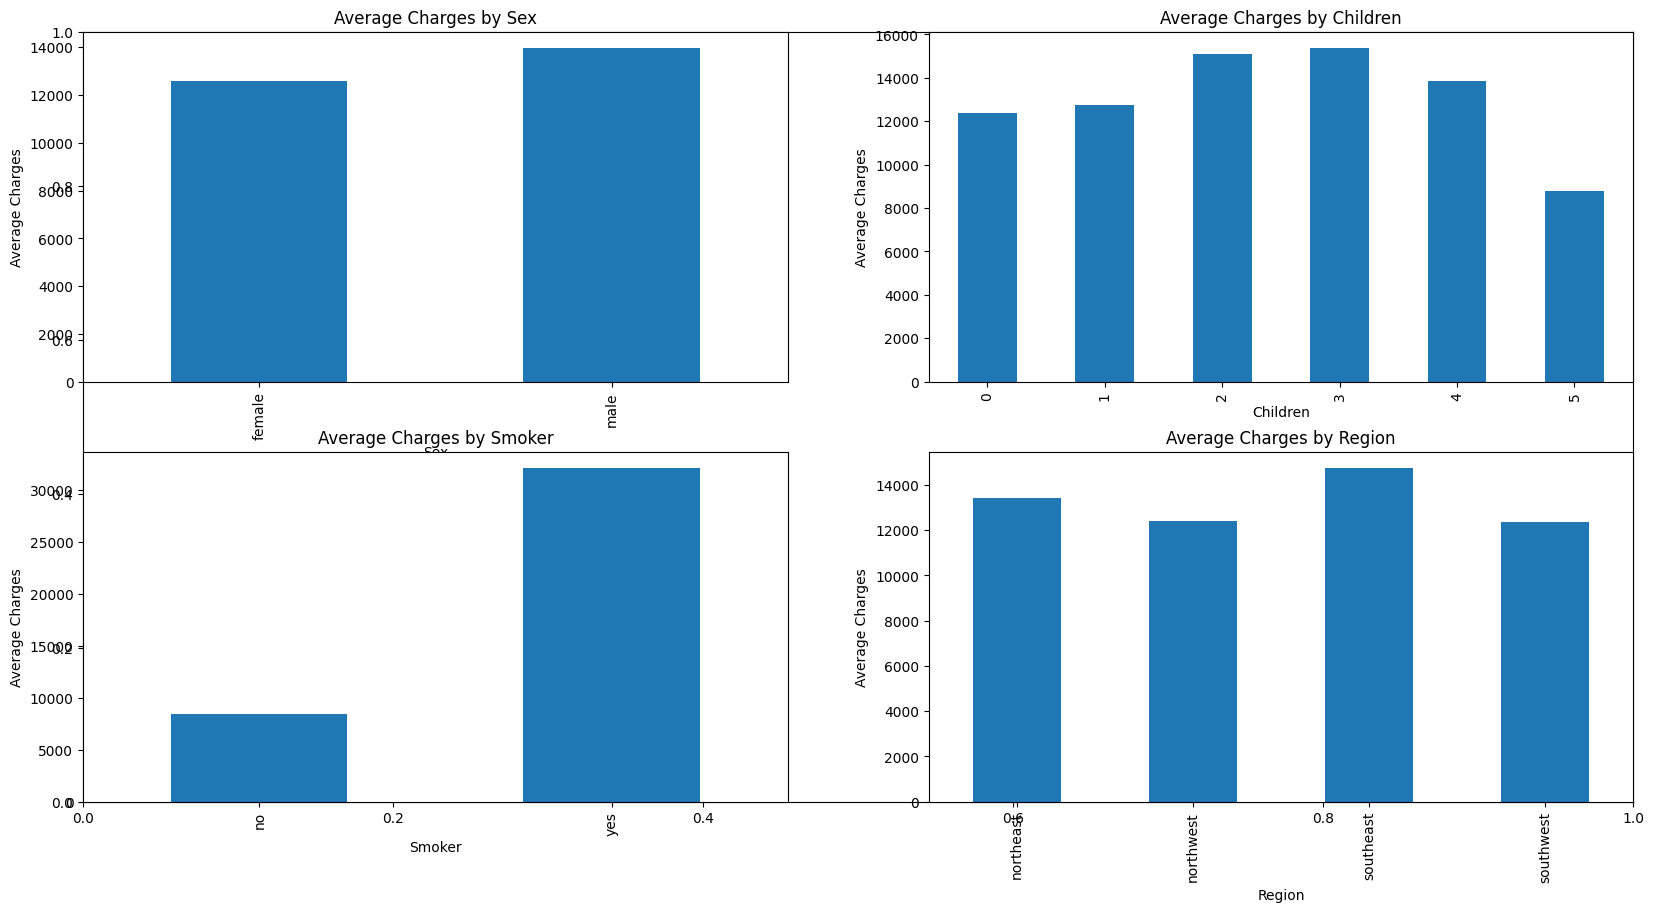

In [33]:
#Plotting the average charges
features = ['sex', 'children', 'smoker', 'region']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col)['charges'].mean().astype(float).plot.bar()
    plt.title(f'Average Charges by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Average Charges')
plt.show()

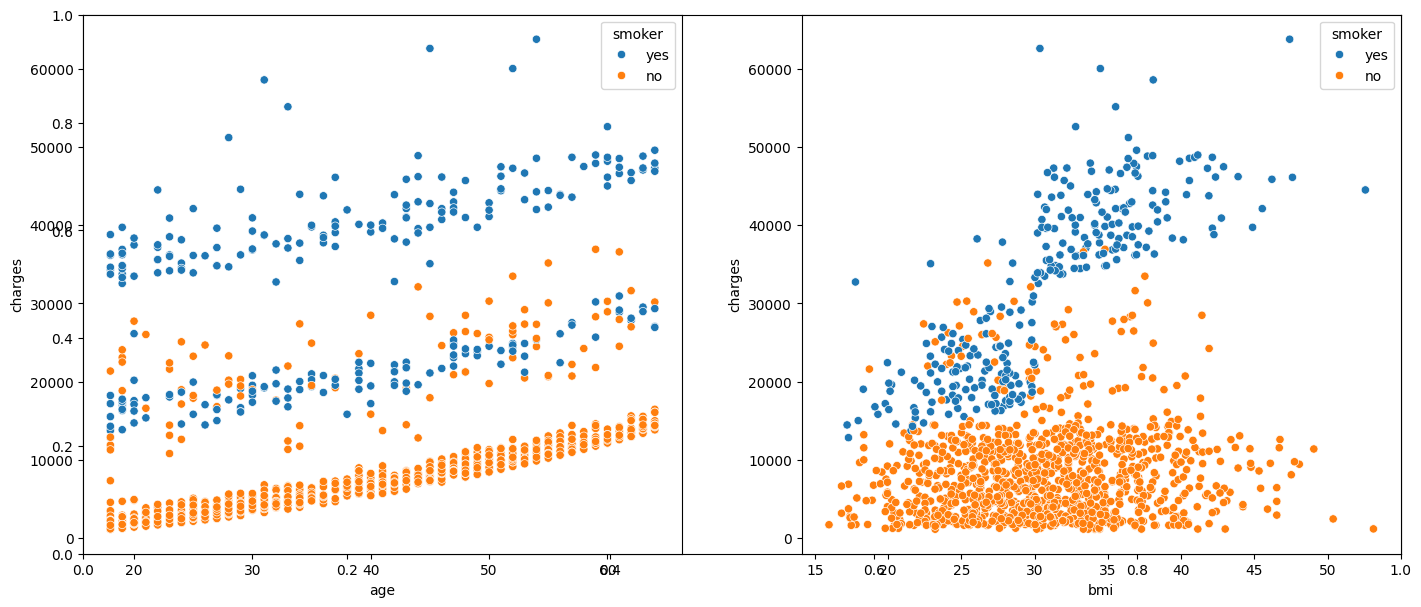

In [34]:
#Plotting the relationship between numerical features and charges
features = ['age', 'bmi']

plt.subplots(figsize=(17, 7))
for i, col in enumerate(features):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(data=df, x=col,
                   y='charges',
                   hue='smoker')
plt.show()

Performing Data Pre Processing

In [35]:
#check duplicates in the dataset
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 1


Text(0, 0.5, 'Count')

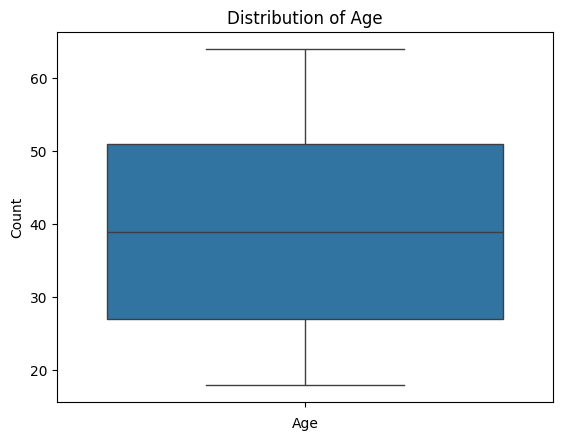

In [36]:
# Removing duplicates from the dataset
df.drop_duplicates(inplace=True)

#Plotting boxplot for age distribution
sns.boxplot(df['age'])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

No oulliers detected in the age distribution column

Text(0, 0.5, 'Count')

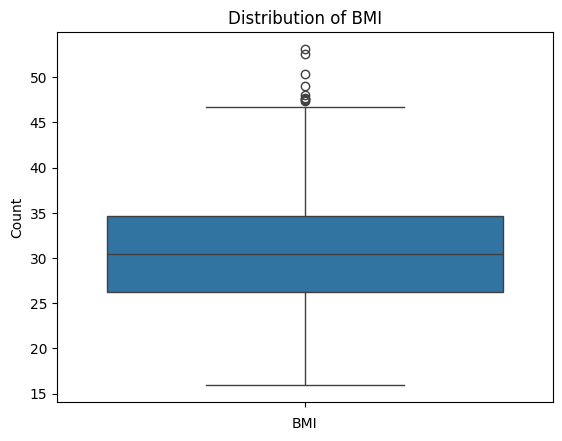

In [37]:
sns.boxplot(df['bmi'])
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')

Outliers detected in the BMI column

In [38]:
# Identifying outliers in the BMI column using IQR method
Q1=df['bmi'].quantile(0.25)
Q2=df['bmi'].quantile(0.5)
Q3=df['bmi'].quantile(0.75)
iqr=Q3-Q1
lowlim=Q1-1.5*iqr
upplim=Q3+1.5*iqr
print(lowlim)
print(upplim)

13.674999999999994
47.31500000000001


<Axes: title={'center': 'Distribution of BMI after capping outliers'}, xlabel='BMI', ylabel='Count'>

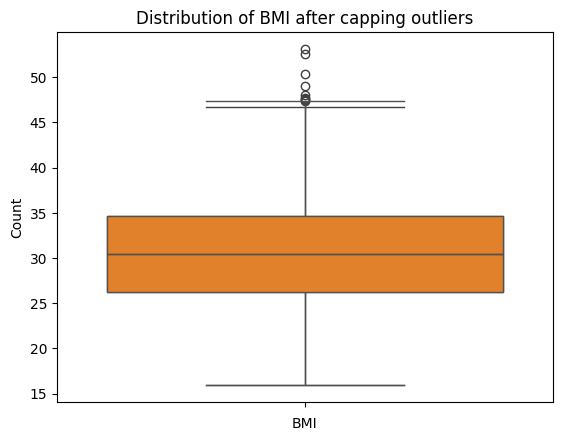

In [39]:
# Capping the outliers in the BMI column
sns.boxplot(df['bmi'])
plt.title('Distribution of BMI after capping outliers')
plt.xlabel('BMI')
plt.ylabel('Count')
from feature_engine.outliers import ArbitraryOutlierCapper
arb=ArbitraryOutlierCapper(min_capping_dict={'bmi':13.6749},max_capping_dict={'bmi':47.315})
df[['bmi']]=arb.fit_transform(df[['bmi']])
sns.boxplot(df['bmi'])

Successfully treated the outliers in the BMI column

Performing Data Wrangling

In [40]:
df['bmi'].skew()
df['age'].skew()

np.float64(0.054780773126998195)

In [41]:
# Encoding the categorical features for our model to perform well
df['sex']=df['sex'].map({'male':0,'female':1})
df['smoker']=df['smoker'].map({'yes':1,'no':0})
df['region']=df['region'].map({'northwest':0, 'northeast':1,'southeast':2,'southwest':3})

In [42]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520


In [44]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.019814,0.111998,0.041536,-0.025587,0.001771,0.298308
sex,0.019814,1.000000,-0.044831,-0.017848,-0.076596,-0.008998,-0.058044
bmi,0.111998,-0.044831,1.000000,0.013692,0.003151,0.156937,0.199063
children,0.041536,-0.017848,0.013692,1.000000,0.007331,-0.002842,0.067389
smoker,-0.025587,-0.076596,0.003151,0.007331,1.000000,0.012736,0.787234
region,0.001771,-0.008998,0.156937,-0.002842,0.012736,1.000000,0.010767
charges,0.298308,-0.058044,0.199063,0.067389,0.787234,0.010767,1.000000


DVELOPING THE COST PREDICTION MODEL

In [56]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

In [47]:
#Separating the features and target variable
X = df.drop(['charges'], axis=1)
Y = df[['charges']]

In [48]:
# Initializing storage for scores
l1 = [] # Train accuracy
l2 = [] # Test accuracy
l3 = [] # Cross-validation scores
cvs = 0

In [49]:
# Looping through different random states (40 to 49)
for i in range(40, 50):
    # Splitting the data into training and testing sets
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=i)
    
    # Initializing and fitting the model
    lrmodel = LinearRegression()
    lrmodel.fit(xtrain, ytrain)
    
    # Recording scores
    l1.append(lrmodel.score(xtrain, ytrain))
    l2.append(lrmodel.score(xtest, ytest))
    
    # Calculating and storing mean cross-validation score
    cvs = (cross_val_score(lrmodel, X, Y, cv=5)).mean()
    l3.append(cvs)

In [50]:
# Creating final results table
df1 = pd.DataFrame({'train acc': l1, 'test acc': l2, 'cvs': l3})
df1

,train acc,test acc,cvs
0,0.741659,0.778409,0.74707
1,0.756401,0.706267,0.74707
2,0.729542,0.806239,0.74707
3,0.754260,0.732791,0.74707
4,0.742966,0.779591,0.74707
5,0.753281,0.731769,0.74707
6,0.741261,0.776456,0.74707
7,0.731940,0.796173,0.74707
8,0.751915,0.741742,0.74707
9,0.756348,0.722565,0.74707


In [51]:
# For a single random state (42)
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=42)
lrmodel=LinearRegression()
lrmodel.fit(xtrain,ytrain)
print(lrmodel.score(xtrain,ytrain))
print(lrmodel.score(xtest,ytest))
print(cross_val_score(lrmodel,X,Y,cv=5,).mean())

0.7295415541376447
0.8062391115570589
0.7470697972809902


Applying Support Vector Regreesor

In [ ]:
# For SVR model
svrmodel=SVR()
svrmodel.fit(xtrain,ytrain)
ypredtrain1=svrmodel.predict(xtrain)
ypredtest1=svrmodel.predict(xtest)
print(r2_score(ytrain,ypredtrain1))
print(r2_score(ytest,ypredtest1))
print(cross_val_score(svrmodel,X,Y,cv=5,).mean())

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-0.10151474302536445
-0.1344454720199666


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

-0.10374591327267262


Applying Random Forest Regressor

In [ ]:
# Initial model training for Random Forest Regressor
rfmodel = RandomForestRegressor(random_state=42)
rfmodel.fit(xtrain, ytrain)

# Initial performance check
ypredtrain2 = rfmodel.predict(xtrain)
ypredtest2 = rfmodel.predict(xtest)
print(f"Baseline Train R2: {r2_score(ytrain, ypredtrain2)}")
print(f"Baseline Test R2: {r2_score(ytest, ypredtest2)}")
print(f"Baseline CV Score: {cross_val_score(rfmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline Train R2: 0.9738163260247533
Baseline Test R2: 0.8819423353068565


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Baseline CV Score: 0.8363637309718952


In [57]:
# Setting up the grid search parameters
estimator = RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [10, 40, 50, 98, 100, 120, 150]}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)


In [58]:
# Running grid search
grid.fit(xtrain, ytrain)

# Displaying the best parameters found
print(f"Best Parameters: {grid.best_params_}")


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Best Parameters: {'n_estimators': 120}


In [59]:
# Training the final model with optimized n_estimators
rfmodel = RandomForestRegressor(random_state=42, n_estimators=120)
rfmodel.fit(xtrain, ytrain)

# Final performance check
ypredtrain2 = rfmodel.predict(xtrain)
ypredtest2 = rfmodel.predict(xtest)
print(f"Final Train R2: {r2_score(ytrain, ypredtrain2)}")
print(f"Final Test R2: {r2_score(ytest, ypredtest2)}")
print(f"Final CV Score: {cross_val_score(rfmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Final Train R2: 0.9746383984429655
Final Test R2: 0.8822009842175969


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Final CV Score: 0.8367438097052858


Applying Gradient Boosting Regressor

In [60]:
# Initial Gradient Boosting model
gbmodel = GradientBoostingRegressor()
gbmodel.fit(xtrain, ytrain)

# Initial performance metrics
ypredtrain3 = gbmodel.predict(xtrain)
ypredtest3 = gbmodel.predict(xtest)
print(f"Baseline Train R2: {r2_score(ytrain, ypredtrain3)}")
print(f"Baseline Test R2: {r2_score(ytest, ypredtest3)}")
print(f"Baseline CV Score: {cross_val_score(gbmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Baseline Train R2: 0.893134582116604
Baseline Test R2: 0.9042686845818371


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y w

Baseline CV Score: 0.8547201820626125


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [61]:
# Defining the model and parameter grid
estimator = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [10, 15, 19, 20, 21, 50],
    'learning_rate': [0.1, 0.19, 0.2, 0.21, 0.8, 1]
}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)

In [62]:
# Fitting the grid search
grid.fit(xtrain, ytrain)

# Output the best settings found
print(f"Best Parameters: {grid.best_params_}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y w

Best Parameters: {'learning_rate': 0.2, 'n_estimators': 19}


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [63]:
# Training the final model with optimized parameters
gbmodel = GradientBoostingRegressor(n_estimators=19, learning_rate=0.2)
gbmodel.fit(xtrain, ytrain)

# Final performance evaluation
ypredtrain3 = gbmodel.predict(xtrain)
ypredtest3 = gbmodel.predict(xtest)
print(f"Final Train R2: {r2_score(ytrain, ypredtrain3)}")
print(f"Final Test R2: {r2_score(ytest, ypredtest3)}")
print(f"Final CV Score: {cross_val_score(gbmodel, X, Y, cv=5).mean()}")

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y w

Final Train R2: 0.8682397447116926
Final Test R2: 0.9017109716082662
Final CV Score: 0.86051471152677


c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
